# MALDROID Machine Learning Notebook

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# -------------- Load Dataset --------------
cic = pd.read_csv("../datasets/CICMal2017 Dataset - Extracted Features with specified APK Benign vs Malicious.csv")
cic['dataset'] = "CICAndMal2017"

drebin = pd.read_csv("../datasets/DREBIN Dataset - APK signatures.csv", low_memory=False)
drebin['dataset'] = "Drebin"

amsf = pd.read_csv("../datasets/AMSF Dataset - Extracted Features with Malware signatures (and Benign vs Malicious).csv")
amsf['dataset'] = "AMSF"

am = pd.read_csv("../datasets/AM.csv", sep=";")
am['dataset'] = "AM"


## Data-preprocessing (Benign = 0, Malicious = 1)


In [2]:
for df in [cic, drebin, am, amsf]:
    df.rename(columns={col: 'class' for col in df.columns if col.lower() in ['label', 'class', 'malware']}, inplace=True)

# ------ CICMAL2017 ------
cic = cic.dropna()

cic_cols = ["App", "Package", "Category", "Description", "Related apps"]
cic = cic.drop(columns=[c for c in cic_cols if c in cic.columns])

binary_map = {
    'True': 1, 'False': 0,
    'true': 1, 'false': 0,
    'YES': 1, 'NO': 0,
    'Yes': 1, 'No': 0,
    'y': 1, 'n': 0
}
cic = cic.replace(binary_map)

bool_cols = cic.select_dtypes(include='bool').columns
cic[bool_cols] = cic[bool_cols].astype(int)

if cic['class'].dtype != int:
    cic['class'] = pd.to_numeric(cic['class'], errors='coerce')
    cic['class'] = cic['class'].fillna(0).astype(int)
    
cic_cleaned = cic.reset_index(drop=True)


# ------ DREBIN ------
drebin['class'] = drebin['class'].replace({'S': 1, 'B': 0}).astype(int)
drebin.replace('?', np.nan, inplace=True)
drebin = drebin.dropna()

# ------ AMSF ------
amsf = amsf.fillna(0)


# ------ AM ------
am['class'] = am['class'].replace({'malware': 1, 'benignware': 0})

am_cols = [
    "name", ".//MD5", "version", ".//Min_SDK", ".//Min_Screen", ".//Min_OpenGL", 
    ".//Supported_CPU", ".//Signature", ".//Developer", ".//Organization", 
    ".//Locality", ".//Country", ".//State", "description"
]
am = am.drop(columns=[c for c in am_cols if c in am.columns])

am.columns = am.columns.str.strip().str.replace(' ', '_').str.lower()

cols = [c for c in am.columns if c not in ['class', 'dataset']]
am_cleaned = am[cols + ['class'] + ['dataset']]


# -------------- Datasets Aggregation --------------
# train_df = pd.concat([drebin, cic_cleaned], axis=0, ignore_index=True)
# train_df = train_df.fillna(0)

# cols = [c for c in train_df.columns if c not in ['class', 'dataset']]
# train_df =train_df[cols + ['class'] + ['dataset']]

list(amsf.columns)

['class',
 'android.app.Activity',
 'android.util.Log.v',
 'android.util.Log.e',
 'android.util.Log.d',
 'java.lang.System',
 'java.util.Arrays',
 'android.widget.VideoView',
 'android.view.animation.AnimationSet',
 'android.graphics.Bitmap.compress',
 'android.content.SharedPreferences',
 'android.database.Cursor',
 'android.graphics.Camera',
 'java.util.Properties',
 'android.content.IntentFilter',
 'android.content.Context.getSharedPreferences',
 'java.lang.String.lastIndexOf',
 'android.view.LayoutInflater',
 'android.view.animation.Transformation',
 'java.io.PrintWriter',
 'android.app.PendingIntent',
 'android.widget.TextView.setTypeface',
 'android.util.Log.i',
 'android.app.NotificationManager',
 'android.database.Cursor.getInt',
 'android.graphics.BitmapFactory.decodeStream',
 'android.widget.ImageView',
 'android.webkit.WebView.setWebViewClient',
 'java.lang.String.compareTo',
 'android.widget.Button.setEnabled',
 'java.io.ObjectInputStream',
 'org.json.JSONObject.getJSONObje

In [3]:
#train_df.to_csv("Aggregated_MALDROID_Datasets.csv", index=False)

## ML Model Training

### Functions and Parameters

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from mrmr import mrmr_classif
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
os.makedirs("models", exist_ok=True)

plt.style.use('seaborn-v0_8')
%matplotlib inline

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()
pca = PCA(n_components=None) 
ros = RandomOverSampler(random_state=42)
smote = SMOTE(random_state=42)

# ---------- Random Forest Parameter ----------

def rf_function(X_train_scaled, y_bal, X_test_scaled, y_test, dataset_name):
    rf_params = {
        'n_estimators': randint(100, 500),
        'max_depth': [3, 5, 7],
        'criterion': ['gini', 'entropy'],
        'class_weight': ['balanced', 'balanced_subsample']
    }
    rf = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), param_distributions=rf_params, cv=skf, n_jobs=-1, verbose=1, scoring='accuracy')
    
    rf = rf.fit(X_train_scaled, y_bal)
    rf_best = rf.best_estimator_
    y_pred = rf_best.predict(X_test_scaled)
    rf_acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n\nRandom Forest Accuracy ({dataset_name} Dataset): {rf_acc:.4f}\n")
    print(classification_report(y_test, y_pred))
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - Random Forest ({dataset_name} Dataset)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # scores = cross_val_score(rf, X_train_scaled, y_bal, cv=skf, scoring='accuracy', n_jobs=-1)
    # print(scores.mean())
    
    return rf_best, rf_acc, cm, y_pred


# ---------- KNN Parameter ----------
def knn_function(X_train_scaled, y_bal, X_test_scaled, y_test, dataset_name):
    knn_params = {
        'n_neighbors': randint(3, 9),
        'weights': ['uniform', 'distance' ],
        'p': [1, 2]
    }
    knn = RandomizedSearchCV(estimator=KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2), param_distributions=knn_params, cv=skf, n_jobs=-1, verbose=1, scoring='accuracy')
    
    knn = knn.fit(X_train_scaled, y_bal)
    knn_best = knn.best_estimator_
    y_pred = knn_best.predict(X_test_scaled)
    knn_acc = accuracy_score(y_test, y_pred)

    print(f"\n\nKNN Accuracy ({dataset_name} Dataset): {knn_acc:.4f}\n")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - KNN ({dataset_name} Dataset)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # scores = cross_val_score(knn, X_train_scaled, y_bal, cv=skf, scoring='accuracy', n_jobs=-1)
    # print(scores.mean())
    
    return knn_best, knn_acc, cm


# ---------- SVM Parameter ----------
def svm_function(X_train_scaled, y_bal, X_test_scaled, y_test, dataset_name):
    param_grid = {
        'C': np.arange(1, 21, 1),
    }
    
    # svm = SVC(random_state=42)
    svm = LinearSVC(random_state=42)
    
    rs_cv = RandomizedSearchCV(estimator=svm, param_distributions=param_grid, cv=skf, n_jobs=-1, verbose=1, scoring='accuracy')
    
    rs_cv.fit(X_train_scaled, y_bal)
    y_pred = rs_cv.predict(X_test_scaled)
    svm_acc = accuracy_score(y_test, y_pred)

    print(f"\n\nSVM Accuracy ({dataset_name} Dataset): {svm_acc:.4f}\n")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - SVM ({dataset_name} Dataset)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # scores = cross_val_score(svm, X_train_scaled, y_bal, cv=skf, scoring='accuracy', n_jobs=-1)
    # print(scores.mean())
    
    return svm, svm_acc, cm


### Drebin Dataset

In [5]:
# -------------- Drebin Variables -----------
X_drebin = drebin.drop(columns=['class', 'dataset'], errors='ignore')
y_drebin = drebin['class']

X_train_drebin, X_test_drebin, y_train_drebin, y_test_drebin = train_test_split(X_drebin, y_drebin, test_size=0.3, random_state=42, stratify=y_drebin ,shuffle=True)

selected_features_drebin = mrmr_classif(X=X_train_drebin, y=y_train_drebin, K=70, n_jobs=-1, show_progress=True)

print(f"Selected {len(selected_features_drebin)} features using mRMR")
print(selected_features_drebin[:10])

X_bal_drebin, y_bal_drebin = ros.fit_resample(X_train_drebin[selected_features_drebin], y_train_drebin)

X_train_scale_drebin = scaler.fit_transform(X_bal_drebin)
X_test_scale_drebin = scaler.transform(X_test_drebin[selected_features_drebin])

X_train_scaled_drebin = pca.fit_transform(X_train_scale_drebin)
X_test_scaled_drebin = pca.transform(X_test_scale_drebin)

100%|██████████| 70/70 [00:15<00:00,  4.62it/s]

Selected 70 features using mRMR
['transact', 'RESTART_PACKAGES', 'TelephonyManager.getLine1Number', 'SEND_SMS', 'onServiceConnected', 'android.os.Binder', 'READ_PHONE_STATE', 'bindService', 'attachInterface', 'android.telephony.SmsManager']


#### Random Forest Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (Drebin Unclean Dataset): 0.9541

              precision    recall  f1-score   support

           0       0.97      0.96      0.96      2843
           1       0.93      0.95      0.94      1667

    accuracy                           0.95      4510
   macro avg       0.95      0.95      0.95      4510
weighted avg       0.95      0.95      0.95      4510

[[2717  126]
 [  81 1586]]


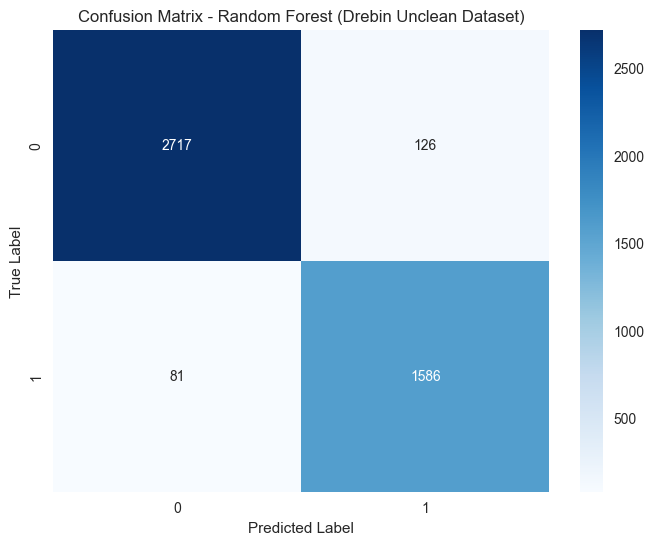

In [6]:
# ----- Drebin Random Forest without RRFS, PCA, Scaler -----
rf_best_drebin, rf_accuracy_drebin, rf_cm_drebin, rf_pred_drebin = rf_function(X_train_drebin, y_train_drebin, X_test_drebin, y_test_drebin, "Drebin Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (Drebin Dataset): 0.9506

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      2843
           1       0.94      0.92      0.93      1667

    accuracy                           0.95      4510
   macro avg       0.95      0.95      0.95      4510
weighted avg       0.95      0.95      0.95      4510

[[2747   96]
 [ 127 1540]]


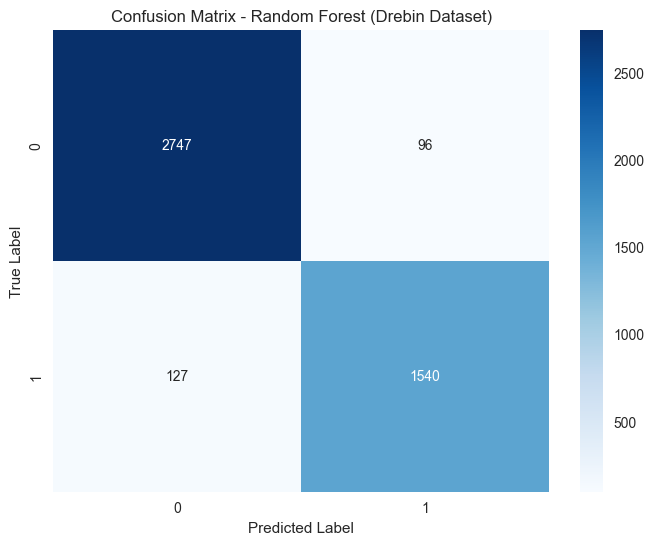

In [6]:
# ----- Drebin Random Forest -----
rf_best_drebin, rf_accuracy_drebin, rf_cm_drebin, rf_pred_drebin = rf_function(X_train_scaled_drebin, y_bal_drebin, X_test_scaled_drebin, y_test_drebin, "Drebin")

#### K-Nearest Neighbour Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KNN Accuracy (Drebin Unclean Dataset): 0.9876

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2843
           1       0.98      0.98      0.98      1667

    accuracy                           0.99      4510
   macro avg       0.99      0.99      0.99      4510
weighted avg       0.99      0.99      0.99      4510

[[2817   26]
 [  30 1637]]


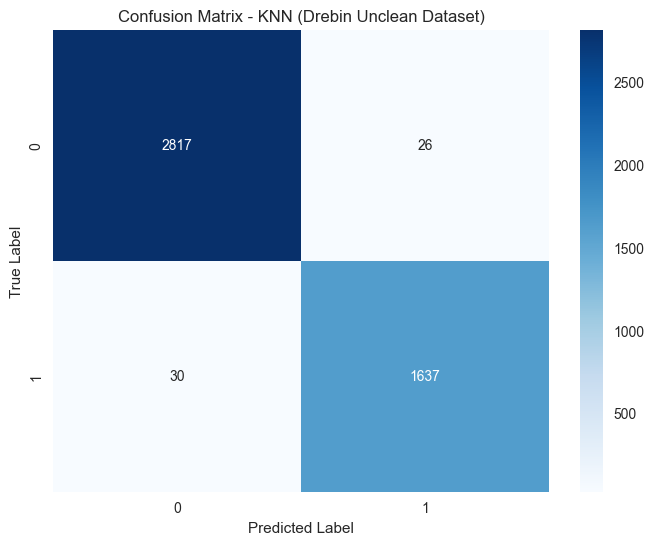

In [8]:
# ----- Drebin KNN without RRFS, PCA, Scaler -----
knn_best_drebin, knn_accuracy_drebin, knn_cm_drebin = knn_function(X_train_drebin, y_train_drebin, X_test_drebin, y_test_drebin, "Drebin Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KNN Accuracy (Drebin Dataset): 0.9568

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      2843
           1       0.94      0.94      0.94      1667

    accuracy                           0.96      4510
   macro avg       0.95      0.95      0.95      4510
weighted avg       0.96      0.96      0.96      4510

[[2752   91]
 [ 104 1563]]


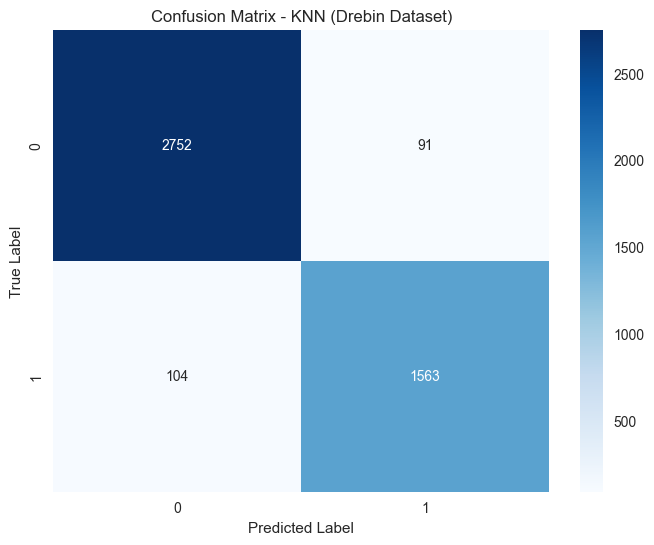

In [7]:
# -------------- Drebin KNN Classifier -----------
knn_best_drebin, knn_accuracy_drebin, knn_cm_drebin = knn_function(X_train_scaled_drebin, y_bal_drebin, X_test_scaled_drebin, y_test_drebin, "Drebin")

#### SVM Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


SVM Accuracy (Drebin Unclean Dataset): 0.9805

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2843
           1       0.98      0.97      0.97      1667

    accuracy                           0.98      4510
   macro avg       0.98      0.98      0.98      4510
weighted avg       0.98      0.98      0.98      4510

[[2806   37]
 [  51 1616]]


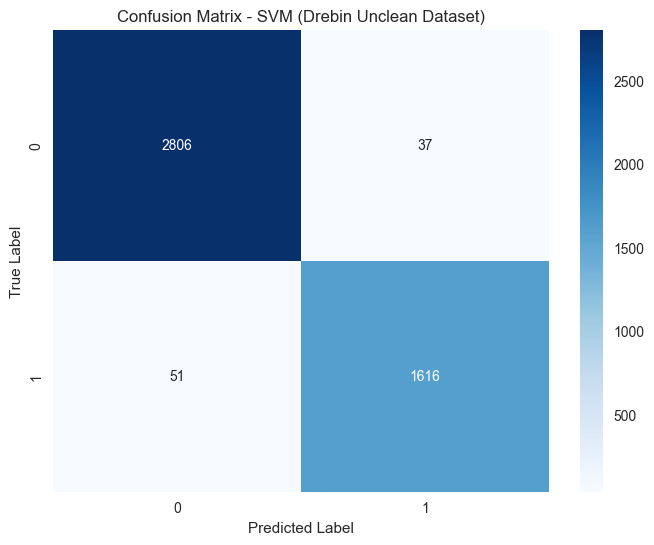

In [9]:
# ----- Drebin SVM without RRFS, PCA, Scaler -----
svm_best_drebin, svm_accuracy_drebin, svm_cm_drebin = svm_function(X_train_drebin, y_train_drebin, X_test_drebin, y_test_drebin, "Drebin Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


SVM Accuracy (Drebin Dataset): 0.9346

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2843
           1       0.90      0.93      0.91      1667

    accuracy                           0.93      4510
   macro avg       0.93      0.93      0.93      4510
weighted avg       0.94      0.93      0.93      4510

[[2667  176]
 [ 119 1548]]


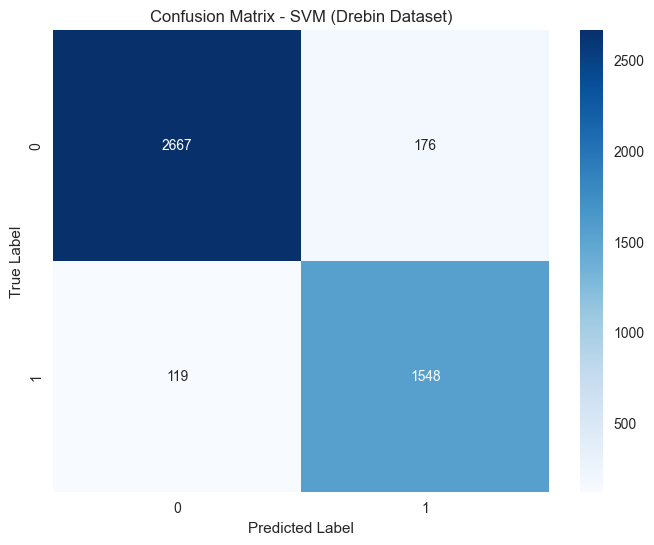

In [8]:
# ------ Drebin SVM Classifier -----------
svm_best_drebin, svm_accuracy_drebin, svm_cm_drebin = svm_function(X_train_scaled_drebin, y_bal_drebin, X_test_scaled_drebin, y_test_drebin, "Drebin")

### AM Dataset

In [6]:
# -------------- AM Variables --------------
X_am = am_cleaned.drop(columns=['class', 'dataset'], errors='ignore')
y_am = am_cleaned['class']

X_train_am, X_test_am, y_train_am, y_test_am = train_test_split(X_am, y_am, test_size=0.3, random_state=42, stratify=y_am ,shuffle=True)

selected_features_am = mrmr_classif(X=X_train_am, y=y_train_am, K=70, n_jobs=-1, show_progress=True)

print(f"Selected {len(selected_features_am)} features using mRMR")
print(selected_features_am[:10])

X_bal_am, y_bal_am = ros.fit_resample(X_train_am[selected_features_am], y_train_am)

X_train_scale_am = scaler.fit_transform(X_bal_am)
X_test_scale_am = scaler.transform(X_test_am[selected_features_am])

pca = PCA(n_components=None) 
X_train_scaled_am = pca.fit_transform(X_train_scale_am)
X_test_scaled_am = pca.transform(X_test_scale_am)

100%|██████████| 70/70 [00:04<00:00, 16.52it/s]


Selected 70 features using mRMR
['com.android.launcher.permission.uninstall_shortcut', 'android.permission.read_sync_settings', 'android.permission.authenticate_accounts', 'android.permission.write_sync_settings', 'android.permission.manage_accounts', 'com.android.launcher.permission.install_shortcut', 'android.permission.read_logs', 'android.permission.use_credentials', 'android.permission.get_accounts', 'android.permission.read_phone_state']


#### Random Forest Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (AM Unclean Dataset): 0.9033

              precision    recall  f1-score   support

           0       0.90      0.97      0.93      2418
           1       0.92      0.74      0.82      1025

    accuracy                           0.90      3443
   macro avg       0.91      0.86      0.88      3443
weighted avg       0.90      0.90      0.90      3443

[[2351   67]
 [ 266  759]]


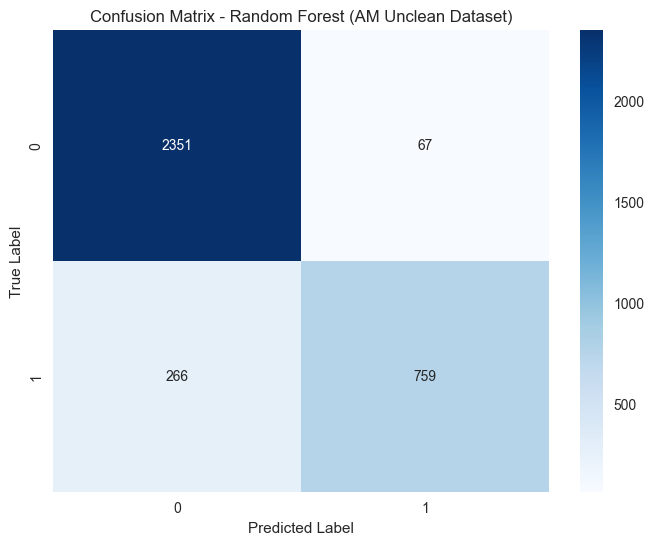

In [16]:
# ----- AM Random Forest without RRFS, PCA, Scaler -----
rf_best_am, rf_accuracy_am, rf_cm_am, rf_pred_am = rf_function(X_train_am, y_train_am, X_test_am, y_test_am, "AM Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (AM Dataset): 0.8969

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      2418
           1       0.84      0.81      0.82      1025

    accuracy                           0.90      3443
   macro avg       0.88      0.87      0.88      3443
weighted avg       0.90      0.90      0.90      3443

[[2261  157]
 [ 198  827]]


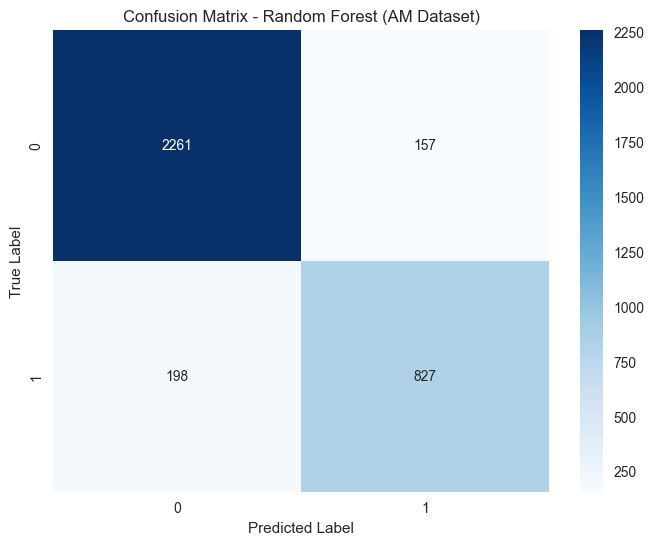

In [10]:
# ----- AM Random Forest -----
rf_best_am, rf_accuracy_am, rf_cm_am, rf_pred_am = rf_function(X_train_scaled_am, y_bal_am, X_test_scaled_am, y_test_am, "AM")

#### K-Nearest Neighbour Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KNN Accuracy (AM Unclean Dataset): 0.8989

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      2418
           1       0.87      0.77      0.82      1025

    accuracy                           0.90      3443
   macro avg       0.89      0.86      0.87      3443
weighted avg       0.90      0.90      0.90      3443

[[2301  117]
 [ 231  794]]


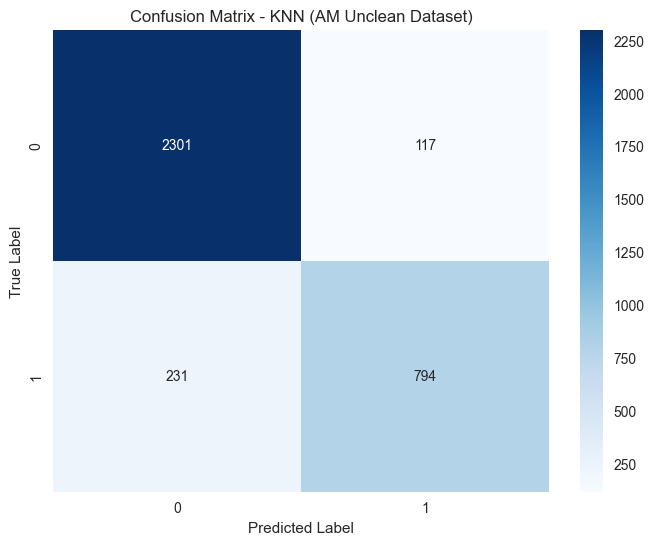

In [ ]:
# ----- AM KNN without RRFS, PCA, Scaler -----
knn_best_am, knn_accuracy_am, knn_cm_am = knn_function(X_train_am, y_train_am, X_test_am, y_test_am, "AM Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KNN Accuracy (AM Dataset): 0.8853

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      2418
           1       0.84      0.76      0.80      1025

    accuracy                           0.89      3443
   macro avg       0.87      0.85      0.86      3443
weighted avg       0.88      0.89      0.88      3443

[[2266  152]
 [ 243  782]]


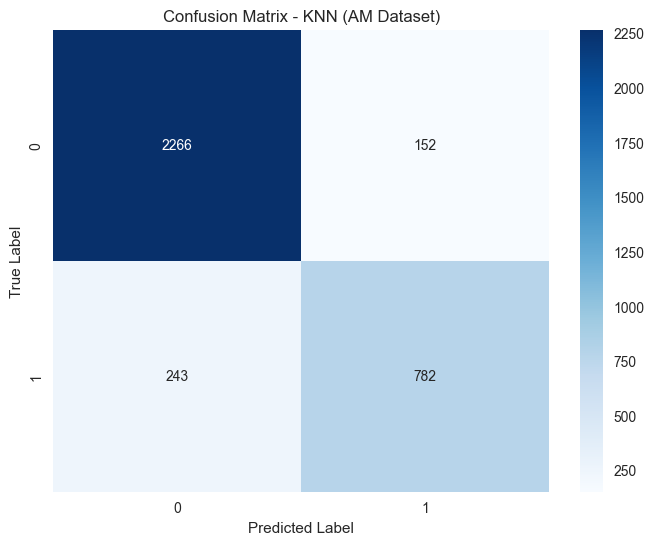

In [ ]:
# ------ AM KNN Classifier -----------
knn_best_am, knn_accuracy_am, knn_cm_am = knn_function(X_train_scaled_am, y_bal_am, X_test_scaled_am, y_test_am, "AM")

#### SVM Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


SVM Accuracy (AM Unclean Dataset): 0.8966

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2418
           1       0.93      0.71      0.80      1025

    accuracy                           0.90      3443
   macro avg       0.91      0.84      0.87      3443
weighted avg       0.90      0.90      0.89      3443

[[2364   54]
 [ 302  723]]


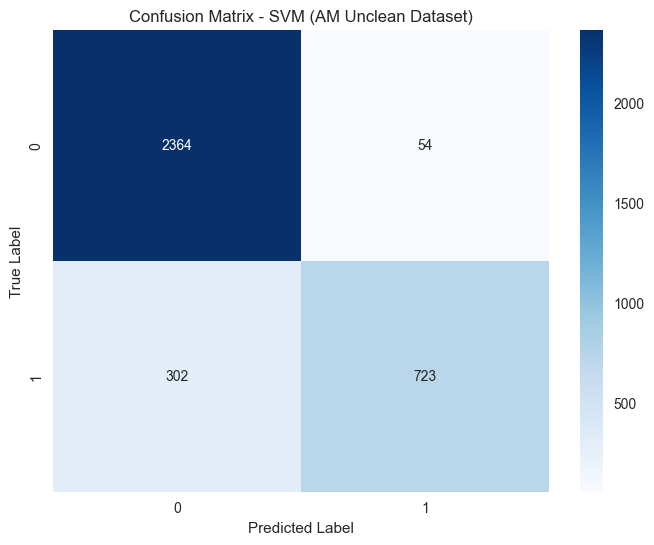

In [18]:
# ----- AM SVM without RRFS, PCA, Scaler -----
svm_best_am, svm_accuracy_am, svm_cm_am = svm_function(X_train_am, y_train_am, X_test_am, y_test_am, "AM Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


SVM Accuracy (AM Dataset): 0.8859

              precision    recall  f1-score   support

           0       0.89      0.96      0.92      2418
           1       0.88      0.71      0.79      1025

    accuracy                           0.89      3443
   macro avg       0.88      0.84      0.85      3443
weighted avg       0.89      0.89      0.88      3443

[[2320   98]
 [ 295  730]]


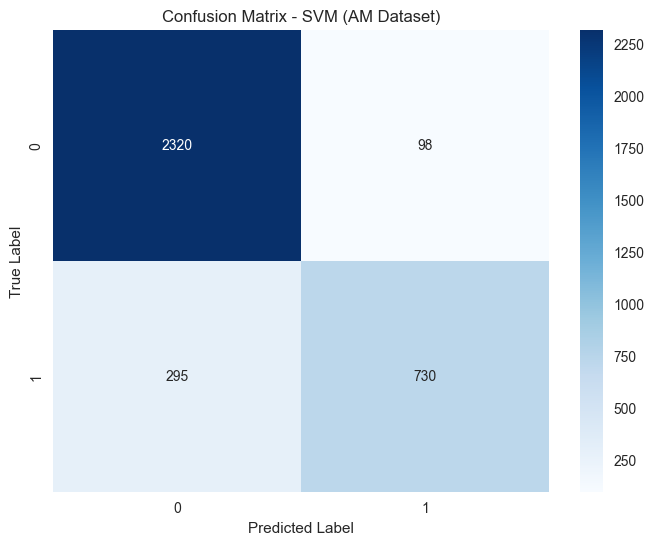

In [12]:
# ------ AM SVM Classifier -----------
svm_best_am, svm_accuracy_am, svm_cm_am = svm_function(X_train_scaled_am, y_bal_am, X_test_scaled_am, y_test_am, "AM")

### AMSF Dataset

In [19]:
# ------ AMSF Variables -----------
X_amsf = amsf.drop(columns=['class', 'dataset'], errors='ignore')
y_amsf = amsf['class']

X_train_amsf, X_test_amsf, y_train_amsf, y_test_amsf = train_test_split(X_amsf, y_amsf, test_size=0.3, random_state=42, stratify=y_amsf ,shuffle=True)

selected_features_amsf = mrmr_classif(X=X_train_amsf, y=y_train_amsf, K=30, n_jobs=-1, show_progress=True)

print(f"Selected {len(selected_features_amsf)} features using mRMR")
print(selected_features_amsf[:10])

X_bal_amsf, y_bal_amsf = ros.fit_resample(X_train_amsf[selected_features_amsf], y_train_amsf)

X_train_scale_amsf = scaler.fit_transform(X_bal_amsf)
X_test_scale_amsf = scaler.transform(X_test_amsf[selected_features_amsf])

X_train_scaled_amsf = pca.fit_transform(X_train_scale_amsf)
X_test_scaled_amsf = pca.transform(X_test_scale_amsf)

100%|██████████| 30/30 [00:07<00:00,  3.84it/s]

Selected 30 features using mRMR
['java.io.PrintWriter', 'android.telephony.SmsManager.sendTextMessage', 'android.view.View.getVisibility', 'android.util.Log.v', 'android.telephony.SmsManager', 'android.view.KeyEvent', 'android.content.Intent.setComponent', 'android.content.Context.getPackageName', 'android.view.animation.AnimationUtils', 'android.content.res.Resources.getDisplayMetrics']


#### Random Forest Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (AMSF Unclean Dataset): 0.9954

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       753
           1       0.99      1.00      1.00       753

    accuracy                           1.00      1506
   macro avg       1.00      1.00      1.00      1506
weighted avg       1.00      1.00      1.00      1506

[[749   4]
 [  3 750]]


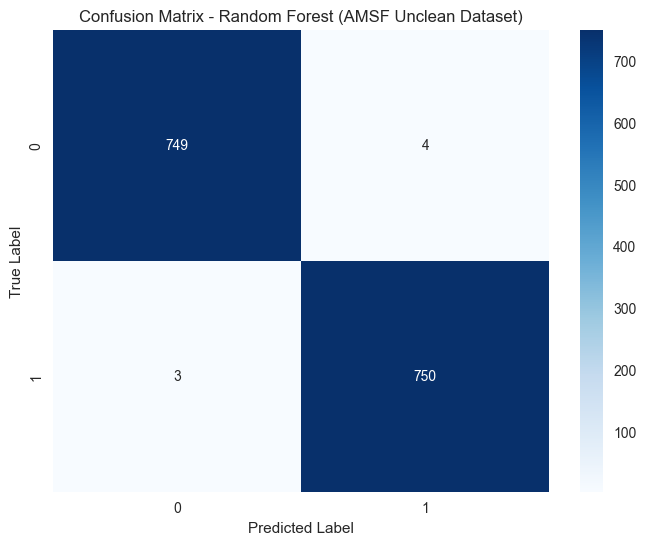

In [20]:
# ----- AMSF Random Forest without RRFS, PCA, Scaler -----
rf_best_amsf, rf_accuracy_amsf, rf_cm_amsf, rf_pred_amsf = rf_function(X_train_amsf, y_train_amsf, X_test_amsf, y_test_amsf, "AMSF Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (AMSF Dataset): 0.9854

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       753
           1       0.99      0.98      0.99       753

    accuracy                           0.99      1506
   macro avg       0.99      0.99      0.99      1506
weighted avg       0.99      0.99      0.99      1506

[[743  10]
 [ 12 741]]


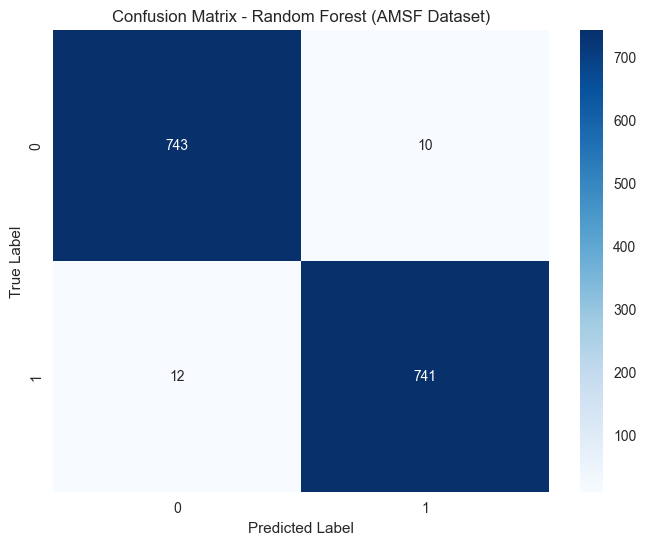

In [14]:
# ------ AMSF Random Forest -----------
rf_best_amsf, rf_accuracy_amsf, rf_cm_amsf, rf_pred_amsf = rf_function(X_train_scaled_amsf, y_bal_amsf, X_test_scaled_amsf, y_test_amsf, "AMSF")

#### K-Nearest Neighbour Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KNN Accuracy (AMSF Unclean Dataset): 0.9914

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       753
           1       0.99      0.99      0.99       753

    accuracy                           0.99      1506
   macro avg       0.99      0.99      0.99      1506
weighted avg       0.99      0.99      0.99      1506

[[748   5]
 [  8 745]]


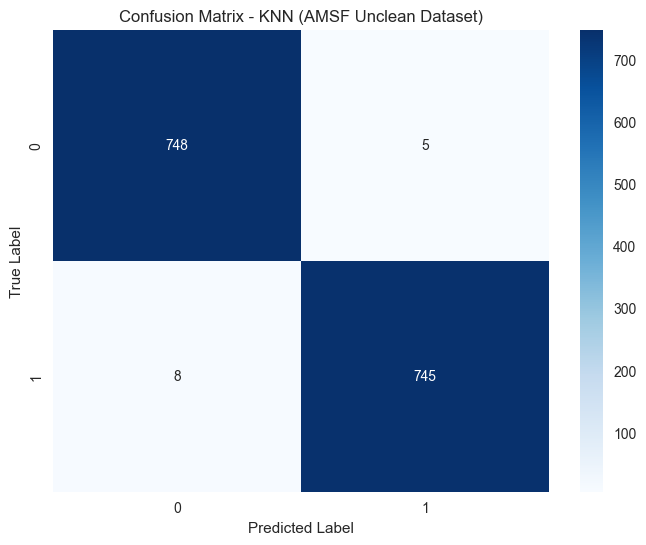

In [21]:
# ----- AMSF KNN without RRFS, PCA, Scaler -----
knn_best_amsf, knn_accuracy_amsf, knn_cm_amsf = knn_function(X_train_amsf, y_train_amsf, X_test_amsf, y_test_amsf, "AMSF Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits




KNN Accuracy (AMSF Dataset): 0.9907

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       753
           1       0.99      0.99      0.99       753

    accuracy                           0.99      1506
   macro avg       0.99      0.99      0.99      1506
weighted avg       0.99      0.99      0.99      1506

[[747   6]
 [  8 745]]


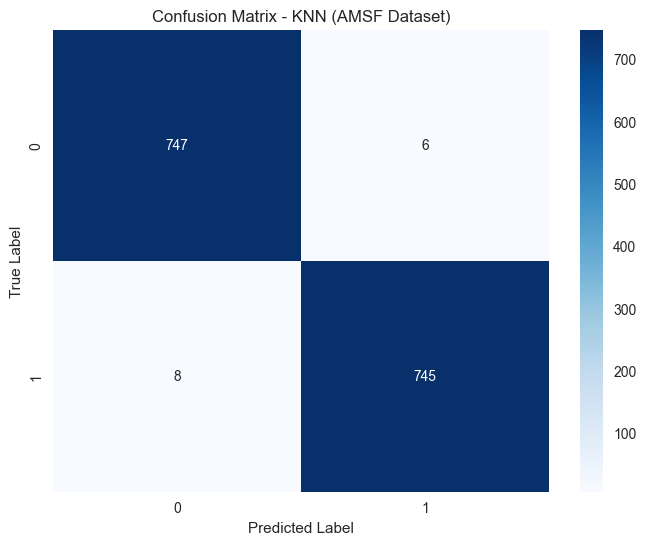

In [15]:
# ------ AMSF KNN Classifier -----------
knn_best_amsf, knn_accuracy_amsf, knn_cm_amsf = knn_function(X_train_scaled_amsf, y_bal_amsf, X_test_scaled_amsf, y_test_amsf, "AMSF")

#### SVM Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


SVM Accuracy (AMSF Unclean Dataset): 0.9854

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       753
           1       0.98      0.99      0.99       753

    accuracy                           0.99      1506
   macro avg       0.99      0.99      0.99      1506
weighted avg       0.99      0.99      0.99      1506

[[736  17]
 [  5 748]]


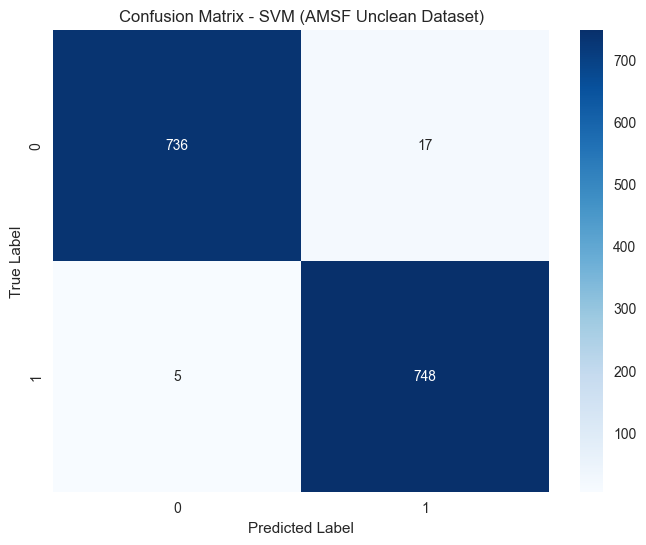

In [22]:
# ----- AMSF SVM without RRFS, PCA, Scaler -----
svm_best_amsf, svm_accuracy_amsf, svm_cm_amsf = svm_function(X_train_amsf, y_train_amsf, X_test_amsf, y_test_amsf, "AMSF Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


SVM Accuracy (AMSF Dataset): 0.9754

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       753
           1       0.97      0.98      0.98       753

    accuracy                           0.98      1506
   macro avg       0.98      0.98      0.98      1506
weighted avg       0.98      0.98      0.98      1506

[[729  24]
 [ 13 740]]


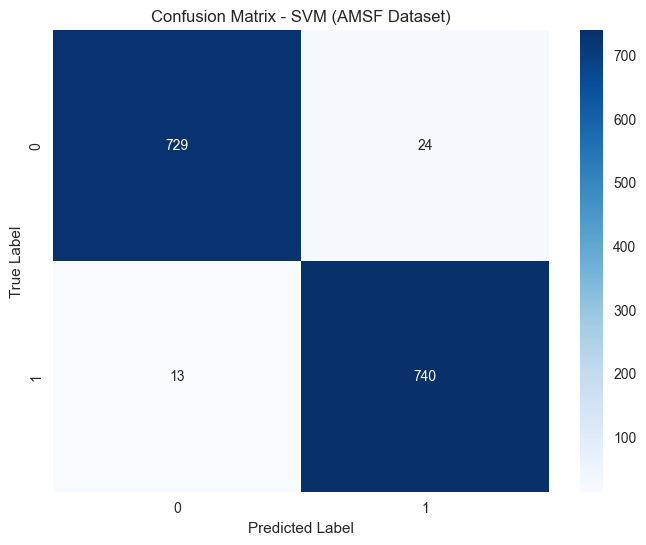

In [16]:
# ------ AMSF SVM Classifier -----------
svm_best_amsf, svm_accuracy_amsf, svm_cm_amsf = svm_function(X_train_scaled_amsf, y_bal_amsf, X_test_scaled_amsf, y_test_amsf, "AMSF")

### CICMAL2017 Dataset

In [11]:
# -------------- CIC Variables --------------
X_cic = cic_cleaned.drop(columns=['class', 'dataset'], errors='ignore')
y_cic = cic_cleaned['class']

X_train_cic, X_test_cic, y_train_cic, y_test_cic = train_test_split(X_cic, y_cic, test_size=0.3, random_state=42, stratify=y_cic ,shuffle=True)

def remove_outliers_iqr(df, cols):
    for col in cols:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            before = df.shape[0]
            df = df[(df[col] >= lower) & (df[col] <= upper)]
            after = df.shape[0]
            print(f"Removed {before - after} outliers from '{col}'")
    return df

numeric_cols_cic = ['rating', 'number_of_ratings', 'price',
                'dangerous_permissions_count', 'safe_permissions_count']

X_train_cic = remove_outliers_iqr(X_train_cic, numeric_cols_cic)

selected_features_cic = mrmr_classif(X=X_train_cic, y=y_train_cic, K=30, n_jobs=-1, show_progress=True)

print(f"Selected {len(selected_features_cic)} features using mRMR")
print(selected_features_cic[:10])

X_bal_cic, y_bal_cic = ros.fit_resample(X_train_cic[selected_features_cic], y_train_cic)

X_train_scale_cic = scaler.fit_transform(X_bal_cic)
X_test_scale_cic = scaler.transform(X_test_cic[selected_features_cic])

X_train_scaled_cic = pca.fit_transform(X_train_scale_cic)
X_test_scaled_cic = pca.transform(X_test_scale_cic)

100%|██████████| 30/30 [00:06<00:00,  4.81it/s]

Selected 30 features using mRMR
['Rating', 'Default : bind to a wallpaper (S)', 'Your location : mock location sources for testing (D)', "Your personal information : write Browser's history and bookmarks (D)", 'Price', 'Default : Access DRM content. (S)', 'Network communication : view network state (S)', 'Default : interact with a device admin (S)', 'Your messages : read instant messages (D)', 'Default : Access download manager. (S)']


#### Random Forest Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (CICandMal2017 Unclean Dataset): 0.6911

              precision    recall  f1-score   support

           0       0.53      0.89      0.66      2973
           1       0.92      0.59      0.72      5799

    accuracy                           0.69      8772
   macro avg       0.72      0.74      0.69      8772
weighted avg       0.78      0.69      0.70      8772

[[2659  314]
 [2396 3403]]


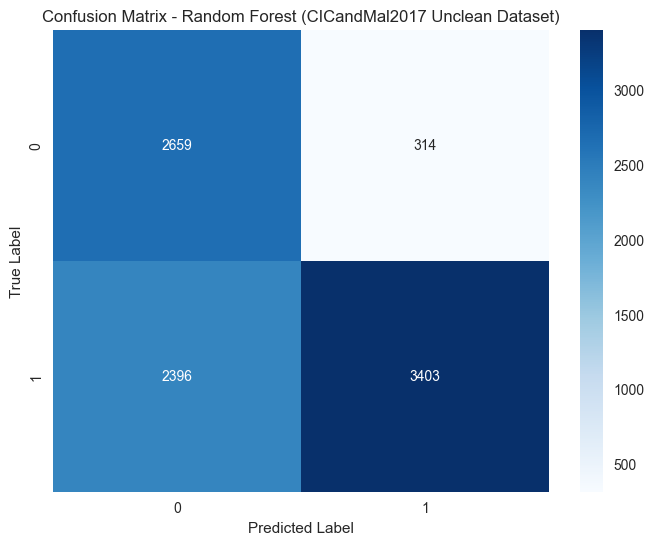

In [12]:
# ----- Drebin Random Forest without RRFS, PCA, Scaler -----
rf_best_cic, rf_accuracy_cic, rf_cm_cic, rf_pred_cic = rf_function(X_train_cic, y_train_cic, X_test_cic, y_test_cic, "CICandMal2017 Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (AM Dataset): 0.6593

              precision    recall  f1-score   support

           0       0.50      0.85      0.63      2973
           1       0.88      0.56      0.69      5799

    accuracy                           0.66      8772
   macro avg       0.69      0.71      0.66      8772
weighted avg       0.75      0.66      0.67      8772

[[2526  447]
 [2542 3257]]


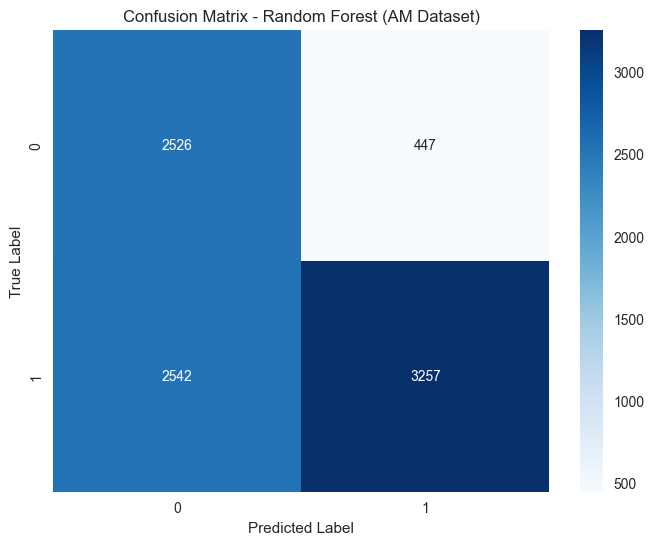

In [ ]:
# ----- CIC Random Forest -----
rf_best_cic, rf_accuracy_cic, rf_cm_cic, rf_pred_cic = rf_function(X_train_scaled_cic, y_bal_cic, X_test_scaled_cic, y_test_cic, "CICandMal2017")

#### K-Nearest Neighbour Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KNN Accuracy (CICandMal2017 Unclean Dataset): 0.7082

              precision    recall  f1-score   support

           0       0.57      0.57      0.57      2973
           1       0.78      0.78      0.78      5799

    accuracy                           0.71      8772
   macro avg       0.67      0.67      0.67      8772
weighted avg       0.71      0.71      0.71      8772

[[1695 1278]
 [1282 4517]]


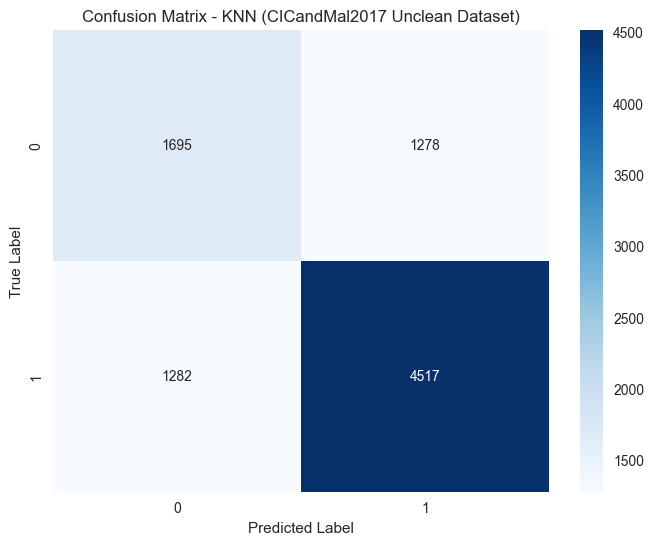

In [13]:
# ----- CICandMal2017 KNN without RRFS, PCA, Scaler -----
knn_best_cic, knn_accuracy_cic, knn_cm_cic = knn_function(X_train_cic, y_train_cic, X_test_cic, y_test_cic, "CICandMal2017 Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KNN Accuracy (CIC Dataset): 0.7026

              precision    recall  f1-score   support

           0       0.56      0.58      0.57      2973
           1       0.78      0.76      0.77      5799

    accuracy                           0.70      8772
   macro avg       0.67      0.67      0.67      8772
weighted avg       0.71      0.70      0.70      8772

[[1729 1244]
 [1365 4434]]


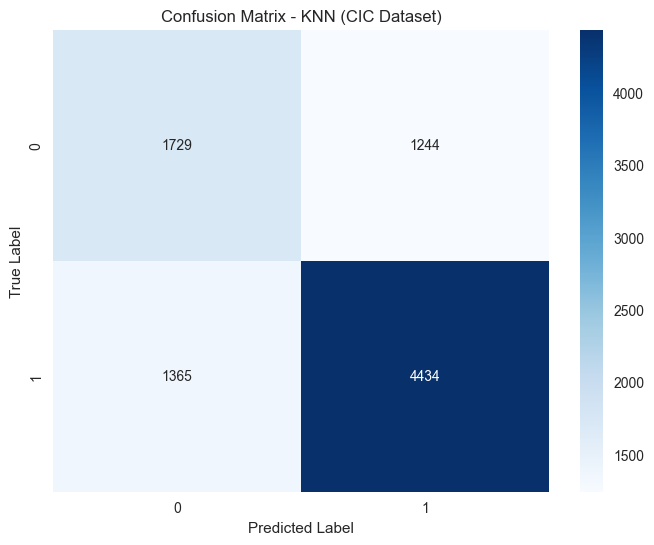

In [ ]:
# ------- CICandMal2017 KNN Classifier --------
knn_best_cic, knn_accuracy_cic, knn_cm_cic = knn_function(X_train_scaled_cic, y_bal_cic, X_test_scaled_cic, y_test_cic, "CICandMal2017")

#### SVM Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


SVM Accuracy (CICandMal2017 Unclean Dataset): 0.6618

              precision    recall  f1-score   support

           0       0.50      0.23      0.32      2973
           1       0.69      0.88      0.78      5799

    accuracy                           0.66      8772
   macro avg       0.60      0.56      0.55      8772
weighted avg       0.63      0.66      0.62      8772

[[ 686 2287]
 [ 680 5119]]


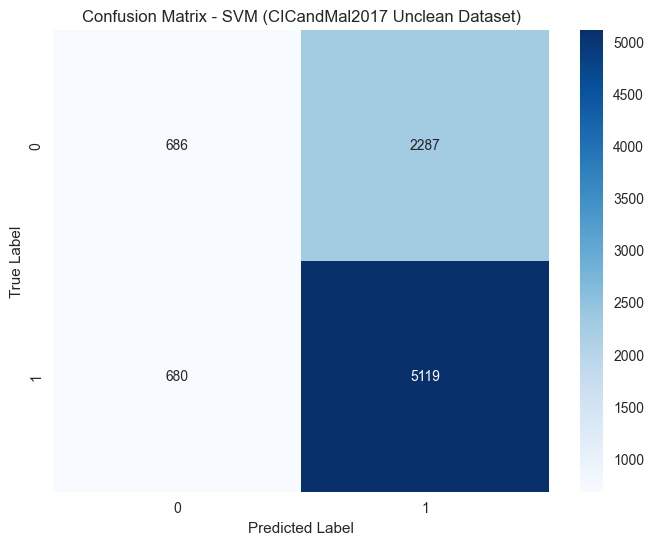

In [14]:
# ----- CICandMal2017 SVM without RRFS, PCA, Scaler -----
svm_best_cic, svm_accuracy_cic, svm_cm_cic = svm_function(X_train_cic, y_train_cic, X_test_cic, y_test_cic, "CICandMal2017 Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


SVM Accuracy (CIC Dataset): 0.6260

              precision    recall  f1-score   support

           0       0.47      0.87      0.61      2973
           1       0.88      0.50      0.64      5799

    accuracy                           0.63      8772
   macro avg       0.68      0.69      0.63      8772
weighted avg       0.74      0.63      0.63      8772

[[2594  379]
 [2902 2897]]


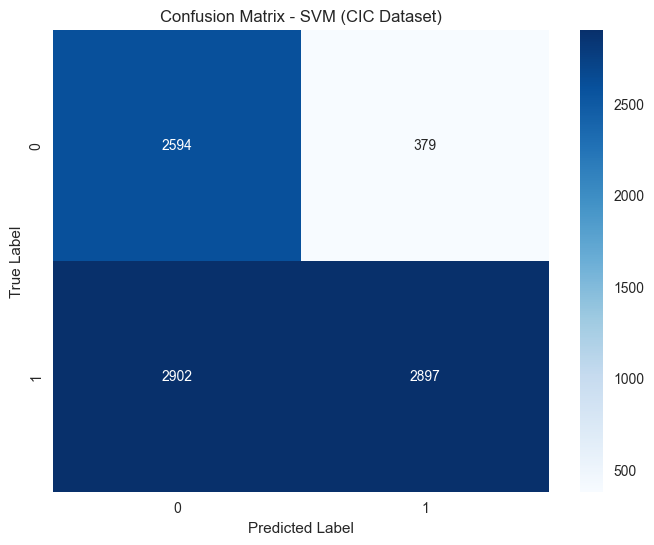

In [ ]:
# ------ CICandMal2017 SVM Classifier -----------
svm_best_cic, svm_accuracy_cic, svm_cm_cic = svm_function(X_train_scaled_cic, y_bal_cic, X_test_scaled_cic, y_test_cic, "CICandMal2017")

### Combined Dataset

In [7]:
# ------ Combined Dataset Variables -----------
combined = pd.concat([drebin, am_cleaned], ignore_index=True)
combined = combined.fillna(0)

X_combined = combined.drop(columns=['class', 'dataset'], errors='ignore')
y_combined = combined['class']

X_train, X_test, y_train, y_test = train_test_split(X_combined, y_combined, test_size=0.3, random_state=42, stratify=y_combined ,shuffle=True)

selected_features_combined = mrmr_classif(
    X=X_train,
    y=y_train,
    K=70,
    n_jobs=-1,
    show_progress=True
)

print(f"Selected {len(selected_features_combined)} features using mRMR")
print(selected_features_combined[:70])

X_bal_combined, y_bal_combined = ros.fit_resample(X_train[selected_features_combined], y_train)

X_train_scale_combined = scaler.fit_transform(X_bal_combined)
X_test_scale_combined = scaler.transform(X_test[selected_features_combined])

pca_rf = PCA(n_components=70)
X_train_scaled_combined = pca_rf.fit_transform(X_train_scale_combined)
X_test_scaled_combined = pca_rf.transform(X_test_scale_combined)


print(y_test.value_counts())
print(y_bal_combined.value_counts())

100%|██████████| 70/70 [00:19<00:00,  3.54it/s]

Selected 70 features using mRMR
['SEND_SMS', 'android.content.pm.Signature', 'ACCESS_LOCATION_EXTRA_COMMANDS', 'com.android.launcher.permission.uninstall_shortcut', 'android.permission.read_sync_settings', 'android.telephony.SmsManager', 'transact', 'android.permission.authenticate_accounts', 'READ_SMS', 'attachInterface', 'android.permission.write_sync_settings', 'WRITE_HISTORY_BOOKMARKS', 'RECEIVE_SMS', 'android.permission.manage_accounts', 'onServiceConnected', 'com.android.launcher.permission.install_shortcut', 'bindService', 'android.telephony.gsm.SmsManager', 'android.permission.read_logs', 'ServiceConnection', 'android.permission.use_credentials', 'INSTALL_PACKAGES', 'TelephonyManager.getLine1Number', 'android.os.Binder', 'createSubprocess', 'Ljava.lang.Class.getMethods', 'READ_HISTORY_BOOKMARKS', 'Ljava.lang.Class.getCanonicalName', 'WRITE_SMS', 'Ljava.lang.Class.cast', 'READ_PHONE_STATE', 'android.permission.get_accounts', 'getBinder', 'android.intent.action.BOOT_COMPLETED', '

In [11]:
scaler = joblib.load("models/malroid_rf_scaler.pkl")
print(f"Scaler expects {scaler.n_features_in_} features")
print(f"Scaler mean shape: {scaler.mean_.shape if hasattr(scaler, 'mean_') else 'No mean'}")
print(f"Scaler scale shape: {scaler.scale_.shape if hasattr(scaler, 'scale_') else 'No scale'}")

pca = joblib.load("models/malroid_rf_pca.pkl")
print(f"PCA expects {pca.n_features_in_} input features")
print(f"PCA components shape: {pca.components_.shape}")
print(f"PCA outputs {pca.n_components_} features")

knn = joblib.load("models/malroid_knn_model.pkl")
print(f"KNN expects {knn.n_features_in_} input features")

Scaler expects 70 features
Scaler mean shape: (70,)
Scaler scale shape: (70,)
PCA expects 70 input features
PCA components shape: (70, 70)
PCA outputs 70 features
KNN expects 70 input features


#### Random Forest Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (Combined Unclean Dataset): 0.9190

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      5261
           1       0.91      0.84      0.88      2692

    accuracy                           0.92      7953
   macro avg       0.92      0.90      0.91      7953
weighted avg       0.92      0.92      0.92      7953

[[5045  216]
 [ 428 2264]]


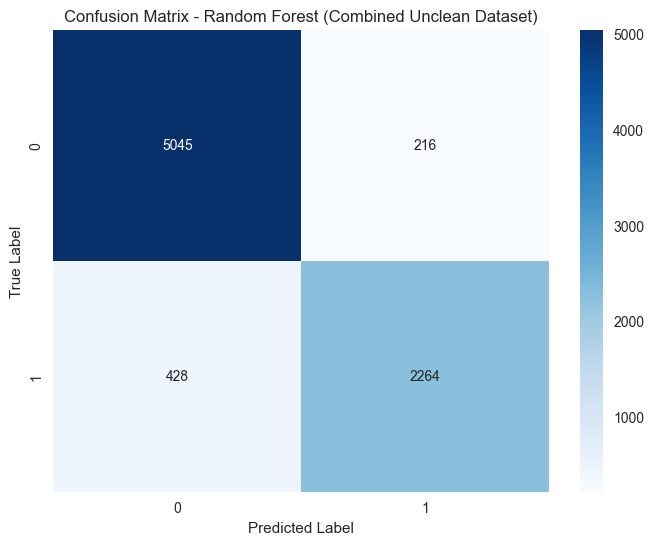

['models/malroid_rf_model.pkl']

In [ ]:
# ------ Combined Dataset Random Forest Classifier w/o RRFS, PCA, and Scaler -----------
rf_best_combined, rf_accuracy_combined, rf_cm_combined, rf_pred_combined = rf_function(X_train, y_train, X_test, y_test, "Combined Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Random Forest Accuracy (Combined Dataset): 0.9325

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5261
           1       0.93      0.86      0.90      2692

    accuracy                           0.93      7953
   macro avg       0.93      0.92      0.92      7953
weighted avg       0.93      0.93      0.93      7953

[[5094  167]
 [ 370 2322]]


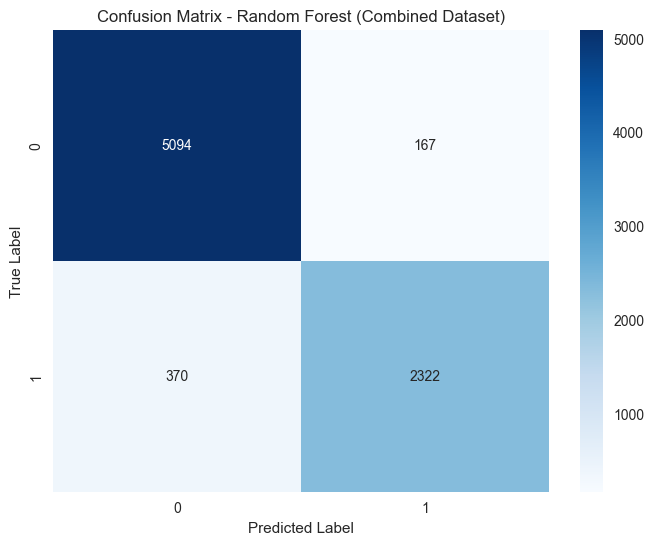

Balanced Accuracy: 0.9154063530088942
ROC-AUC: 0.9626548407878435


In [10]:
# ------ Combined Dataset Random Forest Classifier -----------
rf_best_combined, rf_accuracy_combined, rf_cm_combined, rf_pred_combined = rf_function(X_train_scaled_combined, y_bal_combined, X_test_scaled_combined, y_test, "Combined")

from sklearn.metrics import balanced_accuracy_score, roc_auc_score

y_pred = rf_best_combined.predict(X_test_scaled_combined)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_best_combined.predict_proba(X_test_scaled_combined)[:,1]))

#### KNN Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KNN Accuracy (Combined Unclean Dataset): 0.9497

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      5261
           1       0.95      0.90      0.92      2692

    accuracy                           0.95      7953
   macro avg       0.95      0.94      0.94      7953
weighted avg       0.95      0.95      0.95      7953

[[5124  137]
 [ 263 2429]]


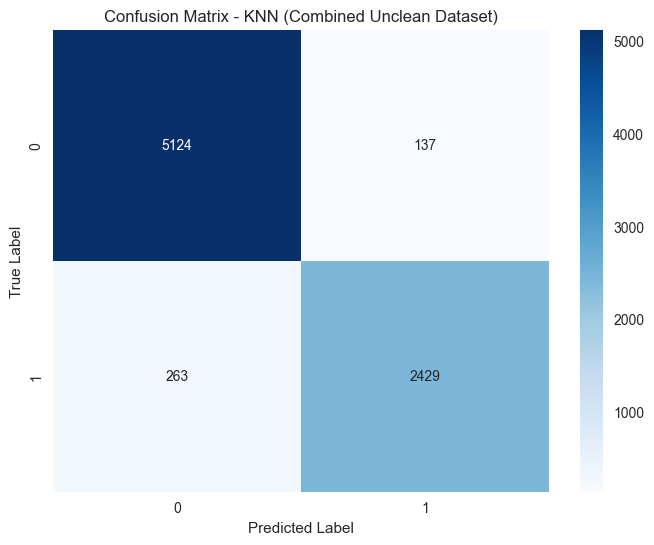

(KNeighborsClassifier(p=1, weights='distance'),
 0.9497045140198667,
 array([[5124,  137],
        [ 263, 2429]]))

In [26]:
# ------ Combined Dataset KNN Classifier w/o RRFS, PCA, and Scaler -----------
knn_function(X_train, y_train, X_test, y_test, "Combined Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KNN Accuracy (Combined Dataset): 0.9365

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      5261
           1       0.94      0.87      0.90      2692

    accuracy                           0.94      7953
   macro avg       0.94      0.92      0.93      7953
weighted avg       0.94      0.94      0.94      7953

[[5108  153]
 [ 352 2340]]


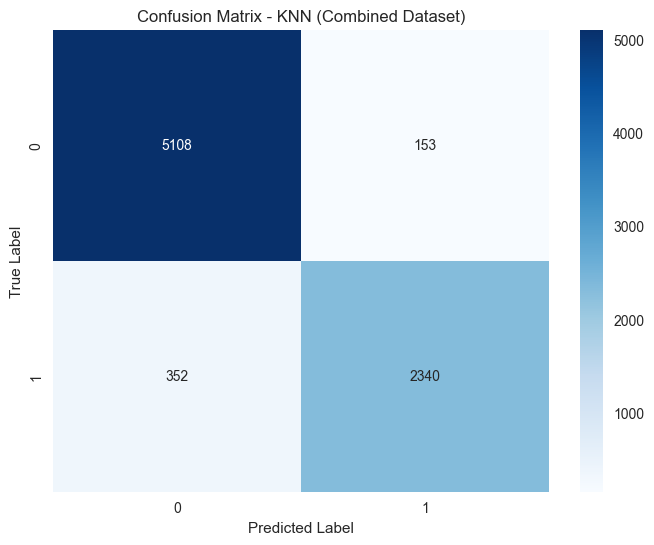

['malroid_knn_model.pkl']

In [9]:
# ------ Combined Dataset KNN Classifier -----------
knn_best_combined, knn_accuracy_combined, knn_cm_combined = knn_function(X_train_scaled_combined, y_bal_combined, X_test_scaled_combined, y_test, "Combined")
joblib.dump(knn_best_combined, 'malroid_knn_model.pkl')

#### SVM Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits


SVM Accuracy (Combined Unclean Dataset): 0.9408

              precision    recall  f1-score   support

           0       0.93      0.98      0.96      5261
           1       0.96      0.86      0.91      2692

    accuracy                           0.94      7953
   macro avg       0.95      0.92      0.93      7953
weighted avg       0.94      0.94      0.94      7953

[[5168   93]
 [ 378 2314]]


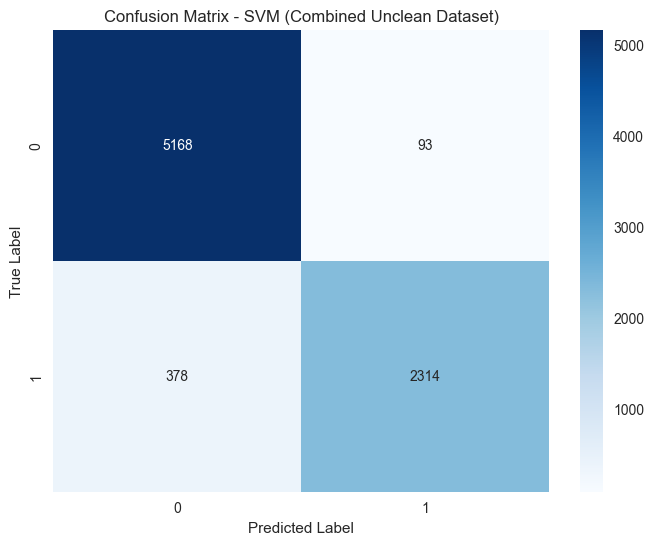

(LinearSVC(random_state=42),
 0.9407770652583931,
 array([[5168,   93],
        [ 378, 2314]]))

In [27]:
# ------ Combined Dataset SVM Classifier w/o RRFS, PCA, and Scaler -----------
svm_function(X_train, y_train, X_test, y_test, "Combined Unclean")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


SVM Accuracy (Combined Dataset): 0.9219

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      5261
           1       0.92      0.84      0.88      2692

    accuracy                           0.92      7953
   macro avg       0.92      0.90      0.91      7953
weighted avg       0.92      0.92      0.92      7953

[[5078  183]
 [ 438 2254]]


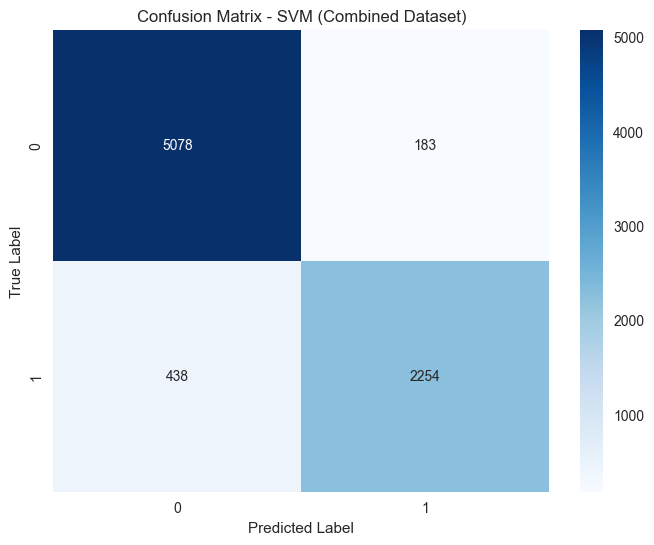

['malroid_svm_model.pkl']

In [35]:
# ------ Combined Dataset SVM Classifier -----------
svm_best_combined, svm_accuracy_combined, svm_cm_combined = svm_function(X_train_scaled_combined, y_bal_combined, X_test_scaled_combined, y_test, "Combined")
joblib.dump(svm_best_combined, 'malroid_svm_model.pkl')

## Ensemble Method

### Weighted Average Accuracy

In [25]:
from sklearn.metrics import f1_score
weights = np.array([30, 30, 10, 30])
accuracies = np.array([rf_accuracy_am, rf_accuracy_amsf, rf_accuracy_cic, rf_accuracy_drebin])

weighted_overall_acc = np.sum(weights * accuracies) / weights.sum()
print("Weighted Overall Accuracy:", weighted_overall_acc)

rf_f1_am    = f1_score(y_test_am, rf_pred_am)
rf_f1_amsf  = f1_score(y_test_amsf, rf_pred_amsf)
rf_f1_cic   = f1_score(y_test_cic, rf_pred_cic)
rf_f1_drebin= f1_score(y_test_drebin, rf_pred_drebin)

f1_scores = np.array([rf_f1_am, rf_f1_amsf, rf_f1_cic, rf_f1_drebin])
weighted_overall_f1 = np.sum(weights * f1_scores) / weights.sum()
print("Weighted Overall F1-Score:", weighted_overall_f1)

Weighted Overall Accuracy: 0.9157771731331309
Weighted Overall F1-Score: 0.8908927140887895


### Weighted Average Probability

In [26]:
X_drebin_all = drebin.drop(columns=['class', 'dataset'], errors='ignore')
y_drebin_all = drebin['class']

X_am_all = am_cleaned.drop(columns=['class', 'dataset'], errors='ignore')
y_am_all = am_cleaned['class']

X_amsf_all = amsf.drop(columns=['class', 'dataset'], errors='ignore')
y_amsf_all = amsf['class']

X_cic_all = cic_cleaned.drop(columns=['class', 'dataset'], errors='ignore')
y_cic_all = cic_cleaned['class']

X_combined = pd.concat([X_drebin_all, X_am_all, X_amsf_all, X_cic_all], axis=0)
y_combined = pd.concat([y_drebin_all, y_am_all, y_amsf_all, y_cic_all], axis=0)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_combined, test_size=0.3, random_state=42, stratify=y_combined
)

In [27]:
from sklearn.impute import SimpleImputer

scaler_drebin, pca_drebin = StandardScaler(), PCA(n_components=0.95)
scaler_am, pca_am         = StandardScaler(), PCA(n_components=0.95)
scaler_amsf, pca_amsf     = StandardScaler(), PCA(n_components=0.95)
scaler_cic, pca_cic       = StandardScaler(), PCA(n_components=0.95)

def fit_transform_pipeline(X_train_subset, X_test_subset, scaler, pca):
    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train_subset)
    X_test_imputed  = imputer.transform(X_test_subset)
    
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    X_train_pca = pca.fit_transform(X_train_scaled)
    
    X_test_scaled = scaler.transform(X_test_imputed)
    X_test_pca = pca.transform(X_test_scaled)
    
    return X_train_pca, X_test_pca

X_train_drebin_pca, X_test_drebin_pca = fit_transform_pipeline(
    X_train[selected_features_drebin], X_test[selected_features_drebin], scaler_drebin, pca_drebin
)
X_train_am_pca, X_test_am_pca = fit_transform_pipeline(
    X_train[selected_features_am], X_test[selected_features_am], scaler_am, pca_am
)
X_train_amsf_pca, X_test_amsf_pca = fit_transform_pipeline(
    X_train[selected_features_amsf], X_test[selected_features_amsf], scaler_amsf, pca_amsf
)
X_train_cic_pca, X_test_cic_pca = fit_transform_pipeline(
    X_train[selected_features_cic], X_test[selected_features_cic], scaler_cic, pca_cic
)

In [28]:
rf_drebin = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_am = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_amsf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_cic = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')

rf_drebin.fit(X_train_drebin_pca, y_train)
rf_am.fit(X_train_am_pca, y_train)
rf_amsf.fit(X_train_amsf_pca, y_train)
rf_cic.fit(X_train_cic_pca, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
probs_drebin = rf_drebin.predict_proba(X_test_drebin_pca)
probs_am     = rf_am.predict_proba(X_test_am_pca)
probs_amsf   = rf_amsf.predict_proba(X_test_amsf_pca)
probs_cic    = rf_cic.predict_proba(X_test_cic_pca)

weights = np.array([rf_accuracy_drebin, rf_accuracy_am, rf_accuracy_amsf, rf_accuracy_cic])
weights = weights / weights.sum()

weighted_probs = (
    weights[0]*probs_drebin +
    weights[1]*probs_am +
    weights[2]*probs_amsf +
    weights[3]*probs_cic
)

weighted_pred_class = np.argmax(weighted_probs, axis=1)
overall_acc = accuracy_score(y_test, weighted_pred_class)
overall_f1  = f1_score(y_test, weighted_pred_class, average='binary')

print("Weighted Ensemble Accuracy:", overall_acc)
print("Weighted Ensemble F1:", overall_f1)

Weighted Ensemble Accuracy: 0.8180471749862863
Weighted Ensemble F1: 0.8285522303199463


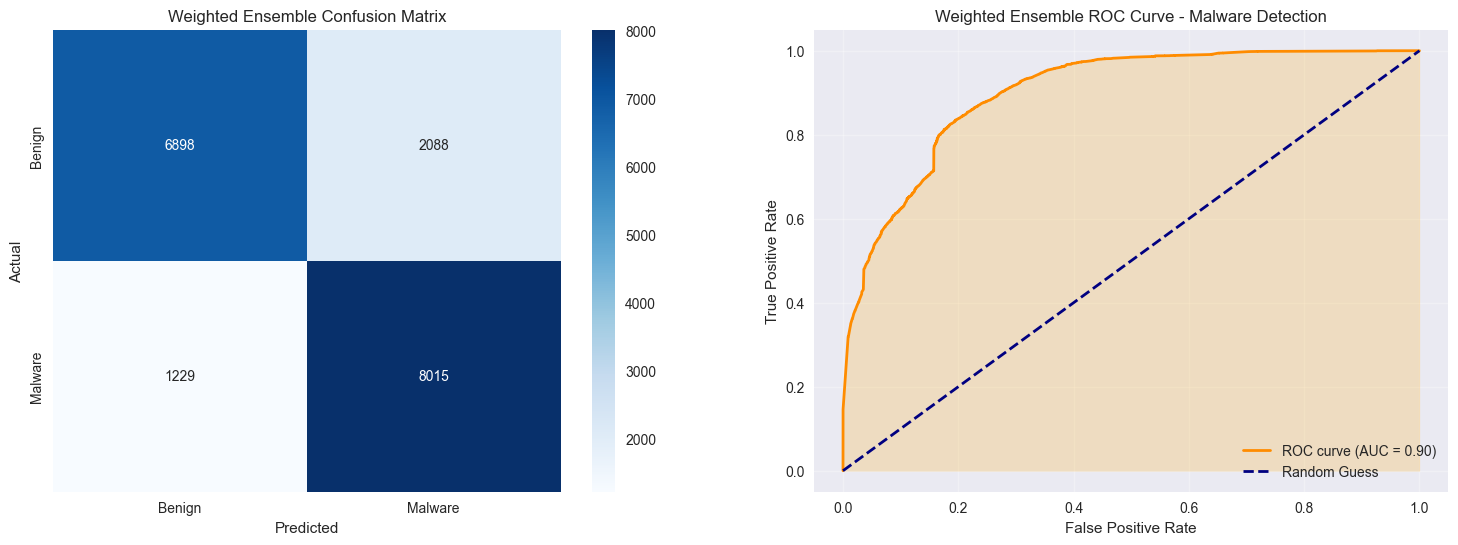

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

class_labels = ['Benign', 'Malware']
cm = confusion_matrix(y_test, weighted_pred_class)

y_test_bin = label_binarize(y_test, classes=[0,1])
y_score = weighted_probs[:,1]  # Malware probability

fpr, tpr, thresholds = roc_curve(y_test_bin, y_score)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(18,6), gridspec_kw={'width_ratios':[1,1], 'wspace':0.2})

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Weighted Ensemble Confusion Matrix')

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0,1], [0,1], color='navy', lw=2, linestyle='--', label='Random Guess')
axes[1].fill_between(fpr, tpr, alpha=0.2, color='orange')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Weighted Ensemble ROC Curve - Malware Detection')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Meta-model Accuracy: 0.8767
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      8986
           1       0.87      0.89      0.88      9244

    accuracy                           0.88     18230
   macro avg       0.88      0.88      0.88     18230
weighted avg       0.88      0.88      0.88     18230

[[7801 1185]
 [1062 8182]]


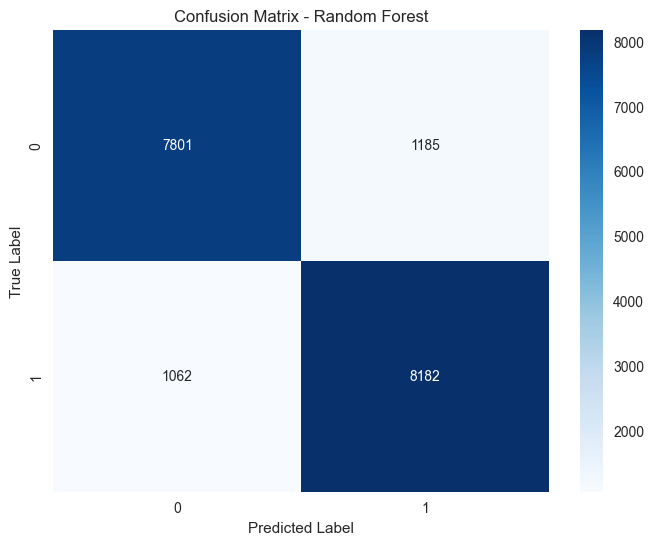

In [31]:
meta_features = np.column_stack([
    rf_drebin.predict_proba(X_test_drebin_pca),
    rf_cic.predict_proba(X_test_cic_pca), 
    rf_am.predict_proba(X_test_am_pca),
    rf_amsf.predict_proba(X_test_amsf_pca)
])

meta_model = RandomForestClassifier(random_state=42)
meta_model.fit(meta_features, y_test)
meta_predictions = meta_model.predict(meta_features)
meta_accuracy = accuracy_score(y_test, meta_predictions)
print(f"Meta-model Accuracy: {meta_accuracy:.4f}")
cm_meta = confusion_matrix(y_test, meta_predictions)

print(classification_report(y_test, meta_predictions))
print(cm_meta)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_meta, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()